In [6]:
%pip install clean-text

   ---------------------------------------- 0.0/610.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/610.9 kB ? eta -:--:--
   ---------------------------------- ----- 524.3/610.9 kB 3.3 MB/s eta 0:00:01
   ---------------------------------- ----- 524.3/610.9 kB 3.3 MB/s eta 0:00:01
   ---------------------------------- ----- 524.3/610.9 kB 3.3 MB/s eta 0:00:01
   ---------------------------------- ----- 524.3/610.9 kB 3.3 MB/s eta 0:00:01
   ---------------------------------- ----- 524.3/610.9 kB 3.3 MB/s eta 0:00:01
   -------------------------------------- 610.9/610.9 kB 247.7 kB/s eta 0:00:00

   ---------------------------------------- 0/3 [ftfy]
   ---------------------------------------- 0/3 [ftfy]
   ---------------------------------------- 0/3 [ftfy]
   ---------------------------------------- 0/3 [ftfy]
   ---------------------------------------- 0/3 [ftfy]
   ---------------------------------------- 0/3 [ftfy]
   ---------------------------------------- 0/3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [11]:
import pandas as pd
from cleantext import clean
import re
import seaborn as sns

In [69]:
data_test = pd.read_csv("186 - emotion-labels-test.csv")
data_train = pd.read_csv("186 - emotion-labels-train.csv")
data_val = pd.read_csv("186 - emotion-labels-val.csv")

In [70]:
data = pd.concat([data_test, data_train, data_val], ignore_index= True)
data.head()

,text,label
0,You must be knowing #blithe means (adj.) Happ...,joy
1,Old saying 'A #smile shared is one gained for ...,joy
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy
3,@Elaminova sparkling water makes your life spa...,joy
4,I'm tired of everybody telling me to chill out...,joy


In [71]:
data['clean'] = data['text'].apply(lambda x: clean(x, no_emoji = True) )

In [72]:
data['clean'] = data['clean'].apply(lambda x: re.sub('@[^\s]+', '', x))
data.head()

,text,label,clean
0,You must be knowing #blithe means (adj.) Happ...,joy,you must be knowing #blithe means (adj.) happy...
1,Old saying 'A #smile shared is one gained for ...,joy,old saying 'a #smile shared is one gained for ...
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy,bridget jones' baby was bloody hilarious #brid...
3,@Elaminova sparkling water makes your life spa...,joy,sparkling water makes your life sparkly
4,I'm tired of everybody telling me to chill out...,joy,i'm tired of everybody telling me to chill out...


<Axes: xlabel='count', ylabel='label'>

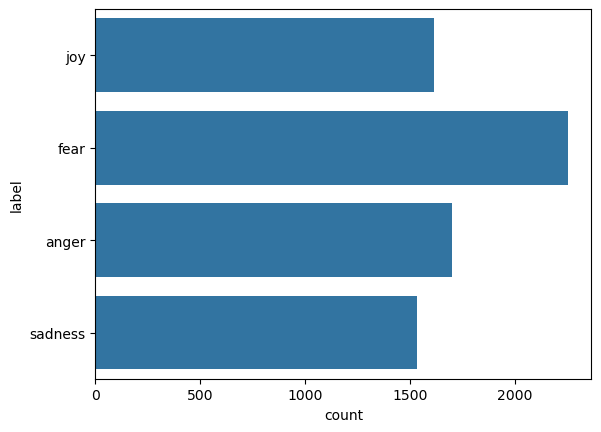

In [ ]:
sns.countplot(data['label'],) # use count plot , dont use bar plot , its just the average 

In [74]:
g = data.groupby('label')
g.head()

,text,label,clean
0,You must be knowing #blithe means (adj.) Happ...,joy,you must be knowing #blithe means (adj.) happy...
1,Old saying 'A #smile shared is one gained for ...,joy,old saying 'a #smile shared is one gained for ...
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy,bridget jones' baby was bloody hilarious #brid...
3,@Elaminova sparkling water makes your life spa...,joy,sparkling water makes your life sparkly
4,I'm tired of everybody telling me to chill out...,joy,i'm tired of everybody telling me to chill out...
714,#Matthew 25; 1-13\nCould somebody shoot a #vid...,fear,#matthew 25; 1-13\ncould somebody shoot a #vid...
715,@bkero @whispersystems Which really sucks beca...,fear,which really sucks because typing on a mobil...
716,Be #afraid of the #quiet ones they are the one...,fear,be #afraid of the #quiet ones they are the one...
717,@riinkanei he's a horrible person and now i ga...,fear,he's a horrible person and now i gag when i s...
718,What we fear doing most is usually what we mos...,fear,what we fear doing most is usually what we mos...


In [ ]:
g = data.groupby('label')
data = pd.DataFrame(  
    g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True))
).reset_index(drop=True)
data.head()

C:\Users\usama\AppData\Local\Temp\ipykernel_16040\475604865.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True))


,text,label,clean
0,srry my feelings offend u 🤗,anger,srry my feelings offend u
1,@bringyouhome2 I'm about to fly into a fit of ...,anger,i'm about to fly into a fit of rage it's not ...
2,@warFarePower dip it in boiling water,anger,dip it in boiling water
3,@DJ_JeanFranko growl!!!,anger,growl!!!
4,@moocowward @mrsajhargreaves @Melly77 @GaryBar...,anger,if he can't come to my mum'a 60th after 25...


<Axes: xlabel='label', ylabel='count'>

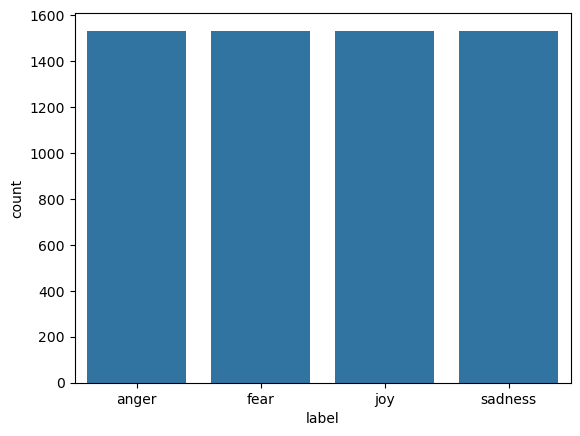

In [76]:
sns.countplot(data= data, x= 'label')